# SensorWatch — Industrial Equipment Health Monitoring

SensorWatch is a machine learning project for predictive maintenance of industrial equipment.

This notebook focuses on predicting the **Remaining Useful Life (RUL)** of an engine using multivariate sensor data from the NASA C-MAPSS dataset.

### Objective

Given an engine's operating history and sensor measurements, predict how many operational cycles remain before the engine reaches the end of its useful life.

### Approach

- Data preprocessing
- Sensor feature engineering
- Time-aware rolling features
- RUL target engineering
- Random Forest regression
- Model evaluation using MAE, MSE and R²

### Dataset

NASA C-MAPSS FD001 Jet Engine Simulated Dataset.

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

 # data = pd.read_csv("train_FD001.txt", sep = r"\s+", header = None)


In [ ]:
RUL_CAP = 125
RANDOM_STATE = 42

In [ ]:
columns = [
    "engine_id", "cycle",
    "setting_1", "setting_2", "setting_3",
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20",
    "sensor_21"
]

data.columns = columns

data.shape

(20631, 26)

##Data Preprocessing

Several sensors in the FD001 dataset have essentially constant values and provide little useful information for predicting degradation. These sensors are removed before modeling.

The dataset is also split by engine rather than by individual rows to prevent information from the same engine appearing in both training and test sets.

In [ ]:
constant_sensors = ["sensor_19", "sensor_18", "sensor_16", "sensor_10", "sensor_5","sensor_1"]

data = data.drop(columns = constant_sensors)

### Remaining Useful Life

RUL represents the number of operational cycles remaining before an engine reaches the end of its recorded life.

For each engine:

RUL = Maximum cycle − Current cycle

In [ ]:
max_cycle = data.groupby("engine_id")["cycle"].transform("max")

data["RUL"] = max_cycle - data["cycle"]


In [ ]:
# Engine level Split

engines = data["engine_id"].unique()

train_engines, test_engines = train_test_split(
    engines,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_mask = data["engine_id"].isin(train_engines)
test_mask = data["engine_id"].isin(test_engines)

##Feature Engineering

Industrial sensor data is time-dependent. A single sensor reading provides information about the current state, but recent sensor behavior can reveal degradation trends.

For each sensor, two rolling features are created using a 5-cycle window:

- Rolling mean — recent average sensor behavior
- Rolling standard deviation — recent sensor variability

In [ ]:
sensor_cols = [
    col for col in data.columns
    if col.startswith("sensor_")
]

features = {}

for col in sensor_cols:
    features[f"{col}_mean_5"] = (
        data.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(5).mean())
    )

    features[f"{col}_std_5"] = (
        data.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(5).std())
    )

rolling_features = pd.DataFrame(
    features,
    index=data.index
)

data = pd.concat(
    [data, rolling_features],
    axis=1
)

In [ ]:
# Preparing X and Y for training and testing

X = data.drop(columns=["RUL", "engine_id"])
y = data["RUL"].clip(upper=RUL_CAP)

In [ ]:
# Applying the engine split

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [ ]:
# Removing the rows where rolling features are not available

train_valid = X_train.notna().all(axis=1)
test_valid = X_test.notna().all(axis=1)

X_train = X_train[train_valid]
y_train = y_train[train_valid]

X_test = X_test[test_valid]
y_test = y_test[test_valid]

##Model Training

A Random Forest Regressor is used to predict RUL.

Random Forest was selected because RUL depends on nonlinear relationships between engine age, operating conditions, and multiple sensor measurements.

The final configuration was selected through hyperparameter experimentation.

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, max_features=0.8, min_samples_leaf=2,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([123.5077697 , 124.2358636 , 124.79213863, ...,   3.72509636,
         2.8703014 ,   0.8811736 ])

## Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} cycles")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.3f}")


MAE: 10.09 cycles
MSE: 228.65
R²: 0.869


## Actual vs Predicted RUL

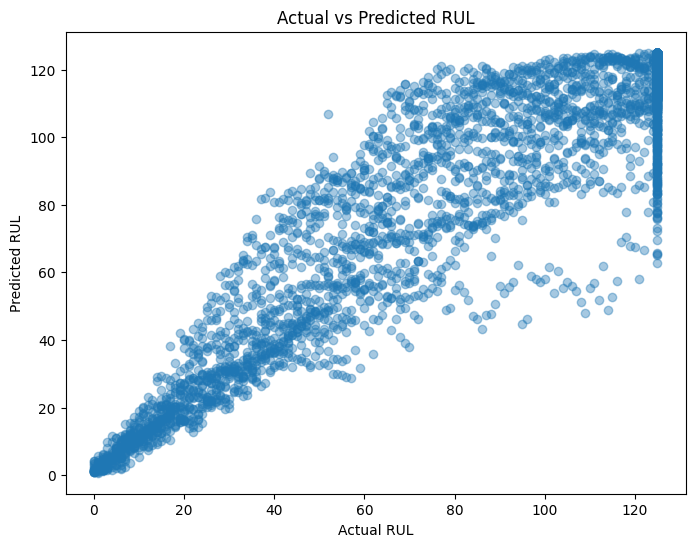

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha = 0.4)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

## Feature Importance

Random Forest provides feature importance scores that indicate which features contributed most to the model's predictions.

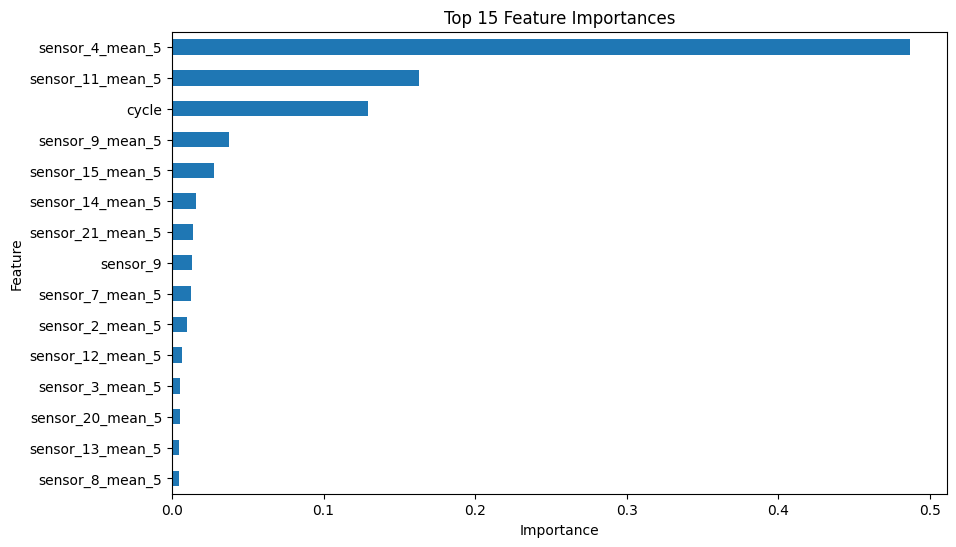

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15)


plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

## Prediction Error Analysis

In [ ]:
error_df = pd.DataFrame({
    "Actual_RUL": y_test,
    "Predicted_RUL": y_pred
})

error_df["Absolute_Error"] = (
    error_df["Actual_RUL"] - error_df["Predicted_RUL"]
).abs()

error_df.describe()

,Actual_RUL,Predicted_RUL,Absolute_Error
count,3990.000000,3990.000000,3990.000000
mean,85.526316,86.440994,10.094697
std,41.771966,39.262778,11.259516
min,0.000000,0.726175,0.005119
25%,49.000000,54.896596,1.622149
50%,99.000000,103.595663,5.861066
75%,125.000000,120.753901,14.495064
max,125.000000,124.992263,65.197923


##  Prediction Error Distribution

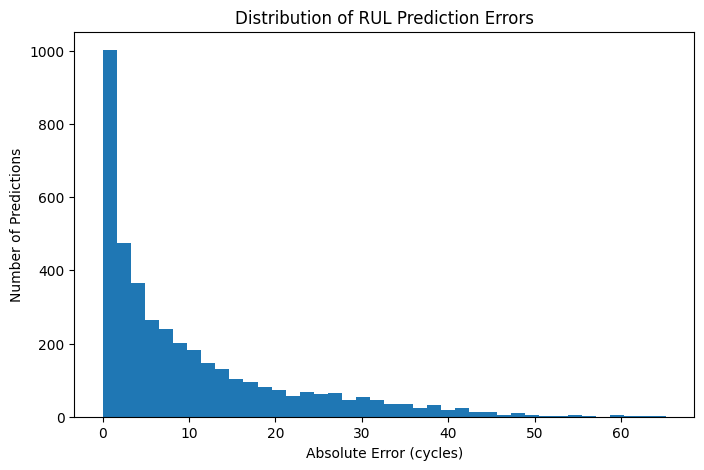

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(error_df["Absolute_Error"], bins=40)

plt.xlabel("Absolute Error (cycles)")
plt.ylabel("Number of Predictions")
plt.title("Distribution of RUL Prediction Errors")

plt.show()

##Final Results

The final SensorWatch RUL model uses a Random Forest Regressor with temporal rolling features and a capped RUL target.

### Performance

- **MAE:** ~10.09 cycles
- **R²:** ~0.869

The model demonstrates a strong relationship between predicted and actual RUL on previously unseen engines. Most prediction errors are relatively small, although some observations show significantly larger errors.

### Key Findings

- Recent sensor behavior captured through rolling features provided important predictive information.
- `sensor_4_mean_5` was the most influential feature in the final model.
- Engine-level splitting ensured that the model was evaluated on engines it had not seen during training.
- RUL capping at 125 cycles helped the model focus on the degradation region most relevant to predictive maintenance.

## Conclusion

SensorWatch successfully predicts the remaining useful life of industrial engines using multivariate sensor data and machine learning.

The next stage of SensorWatch extends beyond RUL prediction to explicit fault detection and diagnosis using the Tennessee Eastman Process dataset.

## Official C-MAPSS FD001 Test Evaluation

In [ ]:
test_data = pd.read_csv("test_FD001.txt", sep = r"\s+", header = None)
test_data.columns = columns

rul_actual = pd.read_csv("RUL_FD001.txt", sep = r"\s+", header = None).iloc [:, 0]

print("Test data shape:", test_data.shape)
print("Actual RUL values:", len(rul_actual))

Test data shape: (13096, 26)
Actual RUL values: 100


In [ ]:
test_data = test_data.drop(columns=constant_sensors)

In [ ]:
sensor_cols = [
    col for col in test_data.columns
    if col.startswith("sensor_")
]

features = {}

for col in sensor_cols:
    features[f"{col}_mean_5"] = (
        test_data.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(5).mean())
    )

    features[f"{col}_std_5"] = (
        test_data.groupby("engine_id")[col]
        .transform(lambda x: x.rolling(5).std())
    )

rolling_features = pd.DataFrame(
    features,
    index=test_data.index
)

test_data = pd.concat(
    [test_data, rolling_features],
    axis=1
)

In [ ]:
test_last = test_data.groupby("engine_id").tail(1)

X_official = test_last.drop(
    columns=["engine_id"]
)

In [ ]:
print(X_official.shape)

(100, 49)


In [ ]:
y_pred_official = model.predict(X_official)
print(y_pred_official[:10])


[121.24313396 120.43301535  46.49707015  76.8084998  101.71410256
  90.35109732 106.9823645   64.17906628 121.78487287 114.87625579]


In [ ]:
# WE WONT BE USING R2 HERE TO TEST


official_mae = mean_absolute_error(
    rul_actual,
    y_pred_official
)

official_mse = mean_squared_error(
    rul_actual,
    y_pred_official
)

official_rmse = np.sqrt(official_mse)

print(f"Official Test MAE: {official_mae:.2f} cycles")
print(f"Official Test RMSE: {official_rmse:.2f} cycles")

Official Test MAE: 13.94 cycles
Official Test RMSE: 18.78 cycles


## 11. Final Results

SensorWatch was evaluated in two stages.

### Internal Engine-Level Evaluation

The model achieved:

- **MAE:** 10.09 cycles
- **R²:** 0.869

This evaluation used an engine-level train/test split from the C-MAPSS FD001 training data.

### Official C-MAPSS FD001 Evaluation

The final model was then evaluated on the official unseen FD001 test set:

- **MAE:** 13.94 cycles
- **RMSE:** 18.78 cycles
- **Test engines:** 100

The official test provides a stronger measure of generalization because these engines were not used during model training.

# A. Fault Detection & Diagnosis with the Tennessee Eastman Process

The C-MAPSS component of SensorWatch focuses on **predictive maintenance** by estimating the Remaining Useful Life (RUL) of an engine.

However, RUL prediction answers only one question:

> **How much useful life remains?**

To make SensorWatch more useful for equipment health monitoring, we also need to determine:

> **Is the equipment operating normally or experiencing a fault?**

For this purpose, SensorWatch uses the **Tennessee Eastman Process (TEP)** dataset.

The TEP dataset contains multivariate process measurements representing normal operation and multiple simulated fault conditions.

### Objective

Build a machine learning system that can:

1. Detect whether the process is operating normally or under a fault.
2. Identify the type of fault when a fault is present.
3. Evaluate how reliably the model distinguishes between different fault conditions.

### Machine Learning Task

Unlike C-MAPSS, where the target is a continuous RUL value, TEP is treated as a **classification problem**.

- **C-MAPSS → Regression → Predict remaining cycles**
- **TEP → Classification → Predict operating condition / fault type**

### Approach

- Load and inspect TEP data
- Prepare sensor measurements and fault labels
- Train a fault classification model
- Evaluate classification performance
- Analyze difficult-to-distinguish fault conditions

The TEP and C-MAPSS datasets are kept as separate modeling tasks because they represent different predictive-maintenance problems.

In [62]:
import os
os.path.getsize("TEP_Faulty_Training.RData") / (1024 ** 3)

0.46013220585882664

In [63]:
!pip install pyreadr -q

In [64]:
import pyreadr

result = pyreadr.list_objects("TEP_Faulty_Training.RData")
result


[{'object_name': 'faulty_training',
  'columns': ['faultNumber',
   'simulationRun',
   'sample',
   'xmeas_1',
   'xmeas_2',
   'xmeas_3',
   'xmeas_4',
   'xmeas_5',
   'xmeas_6',
   'xmeas_7',
   'xmeas_8',
   'xmeas_9',
   'xmeas_10',
   'xmeas_11',
   'xmeas_12',
   'xmeas_13',
   'xmeas_14',
   'xmeas_15',
   'xmeas_16',
   'xmeas_17',
   'xmeas_18',
   'xmeas_19',
   'xmeas_20',
   'xmeas_21',
   'xmeas_22',
   'xmeas_23',
   'xmeas_24',
   'xmeas_25',
   'xmeas_26',
   'xmeas_27',
   'xmeas_28',
   'xmeas_29',
   'xmeas_30',
   'xmeas_31',
   'xmeas_32',
   'xmeas_33',
   'xmeas_34',
   'xmeas_35',
   'xmeas_36',
   'xmeas_37',
   'xmeas_38',
   'xmeas_39',
   'xmeas_40',
   'xmeas_41',
   'xmv_1',
   'xmv_2',
   'xmv_3',
   'xmv_4',
   'xmv_5',
   'xmv_6',
   'xmv_7',
   'xmv_8',
   'xmv_9',
   'xmv_10',
   'xmv_11']}]

In [65]:
import pyreadr

result = pyreadr.read_r("TEP_Faulty_Training.RData")

result.keys()

odict_keys(['faulty_training'])

In [66]:
tep_train = result['faulty_training']
print(tep_train.shape)
print(tep_train.head)
print(tep_train['faultNumber'].value_counts().sort_index())

(5000000, 55)
<bound method NDFrame.head of          faultNumber  simulationRun  sample  xmeas_1  xmeas_2  xmeas_3  \
0                  1            1.0       1  0.25038   3674.0   4529.0   
1                  1            1.0       2  0.25109   3659.4   4556.6   
2                  1            1.0       3  0.25038   3660.3   4477.8   
3                  1            1.0       4  0.24977   3661.3   4512.1   
4                  1            1.0       5  0.29405   3679.0   4497.0   
...              ...            ...     ...      ...      ...      ...   
4999995           20          500.0     496  0.23419   3655.3   4461.7   
4999996           20          500.0     497  0.26704   3647.4   4540.2   
4999997           20          500.0     498  0.26543   3630.3   4571.6   
4999998           20          500.0     499  0.27671   3655.7   4498.9   
4999999           20          500.0     500  0.27421   3640.4   4474.4   

         xmeas_4  xmeas_5  xmeas_6  xmeas_7  ...   xmv_2   xmv_3   

In [67]:
result_normal = pyreadr.read_r("TEP_FaultFree_Training.RData")
result_normal.keys()

odict_keys(['fault_free_training'])

In [70]:
tep_normal = result_normal["fault_free_training"]
print(tep_normal.shape)
print(tep_normal["faultNumber"].value_counts())

(250000, 55)
faultNumber
0.0    250000
Name: count, dtype: int64


In [71]:
import numpy as np

np.random.seed(42)

In [72]:
fault1_df = tep_train[tep_train["faultNumber"] == 1]

fault1_df.shape

(250000, 55)

In [73]:
simulation_ids = fault1_df["simulationRun"].unique()

len(simulation_ids)

500

In [74]:
train_simulations = np.random.choice(
    simulation_ids,
    size=400,
    replace=False
)

test_simulations = np.setdiff1d(
    simulation_ids,
    train_simulations
)

print(len(train_simulations))
print(len(test_simulations))

400
100


In [79]:
train_parts = []
test_parts = []

for fault in range(21):
    if fault == 0:
        df = tep_normal
    else:
        df = tep_train[tep_train["faultNumber"] == fault]

    simulation_ids = df["simulationRun"].unique()

    train_simulations = np.random.choice(
        simulation_ids,
        size=400,
        replace=False
    )

    test_simulations = np.setdiff1d(
        simulation_ids,
        train_simulations
    )

    train_parts.append(
        df[df["simulationRun"].isin(train_simulations)]
    )

    test_parts.append(
        df[df["simulationRun"].isin(test_simulations)]
    )

tep_train_split = pd.concat(train_parts, ignore_index=True)
tep_test_split = pd.concat(test_parts, ignore_index=True)

print("Train:", tep_train_split.shape)
print("Test:", tep_test_split.shape)

Train: (4200000, 55)
Test: (1050000, 55)


In [80]:
tep_train_split = tep_train_split[
    tep_train_split["sample"] % 10 == 0
].reset_index(drop=True)

tep_test_split = tep_test_split[
    tep_test_split["sample"] % 10 == 0
].reset_index(drop=True)

print("Train:", tep_train_split.shape)
print("Test:", tep_test_split.shape)

Train: (420000, 55)
Test: (105000, 55)


In [81]:
feature_cols = [
    col for col in tep_train_split.columns
    if col.startswith("xmeas_") or col.startswith("xmv_")
]

X_train_tep = tep_train_split[feature_cols]
y_train_tep = tep_train_split["faultNumber"]

X_test_tep = tep_test_split[feature_cols]
y_test_tep = tep_test_split["faultNumber"]

print("X_train:", X_train_tep.shape)
print("y_train:", y_train_tep.shape)
print("X_test:", X_test_tep.shape)
print("y_test:", y_test_tep.shape)

X_train: (420000, 52)
y_train: (420000,)
X_test: (105000, 52)
y_test: (105000,)


In [82]:
from sklearn.ensemble import RandomForestClassifier

tep_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

tep_model.fit(X_train_tep, y_train_tep)

RandomForestClassifier(max_depth=15, min_samples_leaf=2, n_estimators=150,
                       n_jobs=-1, random_state=42)

In [83]:
y_pred_tep = tep_model.predict(X_test_tep)

print(y_pred_tep[:20])

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 15. 10. 10. 10.
 10.  0.]


In [84]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy = accuracy_score(y_test_tep, y_pred_tep)

print(f"Accuracy: {accuracy:.4f}")
print()
print(classification_report(y_test_tep, y_pred_tep))

Accuracy: 0.6528

              precision    recall  f1-score   support

         0.0       0.14      0.84      0.23      5000
         1.0       0.99      0.96      0.97      5000
         2.0       1.00      0.94      0.97      5000
         3.0       0.11      0.03      0.05      5000
         4.0       0.90      0.95      0.93      5000
         5.0       0.67      0.66      0.67      5000
         6.0       1.00      0.96      0.98      5000
         7.0       1.00      0.96      0.98      5000
         8.0       0.95      0.84      0.89      5000
         9.0       0.07      0.00      0.00      5000
        10.0       0.61      0.50      0.55      5000
        11.0       0.89      0.65      0.75      5000
        12.0       0.80      0.85      0.83      5000
        13.0       0.98      0.81      0.88      5000
        14.0       0.97      0.91      0.94      5000
        15.0       0.13      0.02      0.04      5000
        16.0       0.84      0.31      0.45      5000
        1

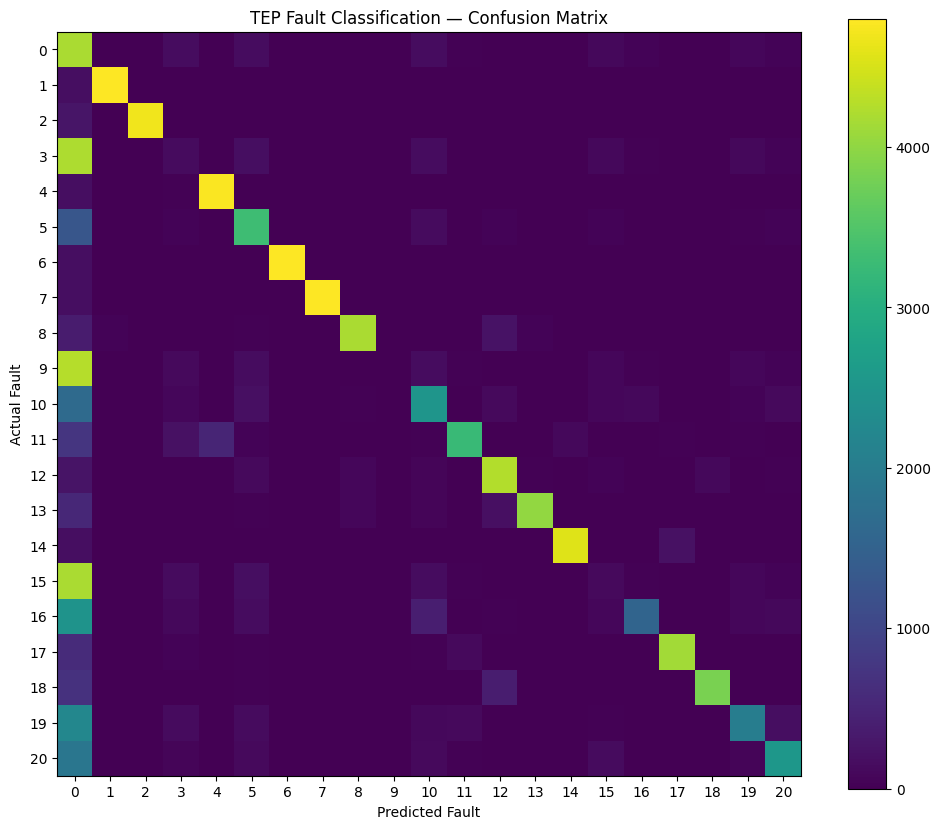

In [85]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_tep, y_pred_tep)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Fault")
plt.ylabel("Actual Fault")
plt.title("TEP Fault Classification — Confusion Matrix")

plt.xticks(range(21), range(21))
plt.yticks(range(21), range(21))

plt.show()

In [87]:
tep_report = pd.DataFrame(
    classification_report(
        y_test_tep,
        y_pred_tep,
        output_dict=True
    )
).T

tep_report = tep_report.iloc[:21]

tep_report.sort_values("f1-score")

,precision,recall,f1-score,support
9.0,0.069767,0.0012,0.002359,5000.0
15.0,0.127155,0.0236,0.039811,5000.0
3.0,0.107815,0.0298,0.046694,5000.0
0.0,0.136577,0.8382,0.234882,5000.0
16.0,0.844809,0.3092,0.452709,5000.0
19.0,0.748620,0.4068,0.527148,5000.0
10.0,0.605314,0.5012,0.548359,5000.0
20.0,0.789572,0.5088,0.618828,5000.0
5.0,0.669630,0.6628,0.666198,5000.0
11.0,0.885691,0.6524,0.751353,5000.0


## 20. TEP Fault Diagnosis Results

The TEP classifier was evaluated on 105,000 samples from previously unseen simulation runs.

### Overall Performance

- **Accuracy:** 65.28%
- **Number of classes:** 21
- **Classes:** Normal operation + 20 fault conditions
- **Input features:** 52 process variables
  - 41 measured variables (`xmeas`)
  - 11 manipulated variables (`xmv`)

The model demonstrates strong performance on several fault conditions, while some faults remain difficult to distinguish from other process states.

### Difficult Fault Conditions

The lowest F1-scores were observed for:

- Fault 9
- Fault 15
- Fault 3
- Normal operation
- Fault 16
- Fault 19
- Fault 10
- Fault 20

This indicates that certain process faults have sensor patterns that overlap significantly with other operating conditions.

### Key Observation

The confusion matrix shows that TEP fault diagnosis is substantially more difficult than simply detecting whether a fault exists. Some fault types are highly distinguishable, while others require more sophisticated temporal modeling or additional feature engineering.

The current Random Forest model therefore provides a strong baseline for SensorWatch rather than a claim of perfect fault diagnosis.

In [88]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_test_binary = (y_test_tep != 0).astype(int)
y_pred_binary = (y_pred_tep != 0).astype(int)

binary_accuracy = accuracy_score(
    y_test_binary,
    y_pred_binary
)

print(f"Binary Fault Detection Accuracy: {binary_accuracy:.4f}")
print()
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=["Normal", "Fault"]
))

Binary Fault Detection Accuracy: 0.7400

              precision    recall  f1-score   support

      Normal       0.14      0.84      0.23      5000
       Fault       0.99      0.74      0.84    100000

    accuracy                           0.74    105000
   macro avg       0.56      0.79      0.54    105000
weighted avg       0.95      0.74      0.81    105000



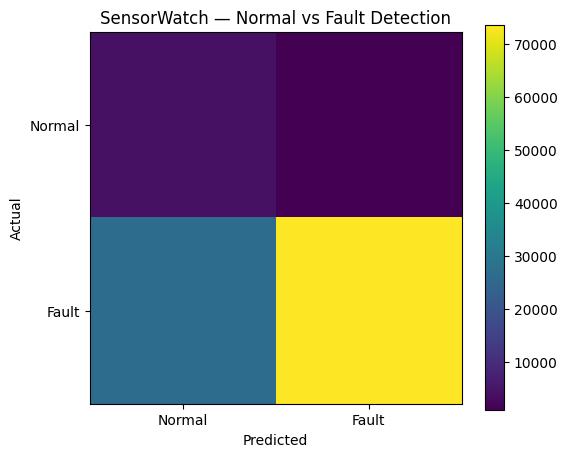

In [89]:
cm_binary = confusion_matrix(
    y_test_binary,
    y_pred_binary
)

plt.figure(figsize=(6, 5))
plt.imshow(cm_binary)
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SensorWatch — Normal vs Fault Detection")

plt.xticks([0, 1], ["Normal", "Fault"])
plt.yticks([0, 1], ["Normal", "Fault"])

plt.show()

# SensorWatch — Final Results

SensorWatch combines two complementary predictive-maintenance tasks using two different industrial datasets.

## 1. Remaining Useful Life Prediction — NASA C-MAPSS

The C-MAPSS component predicts the remaining operational cycles of an engine.

### Internal Engine-Level Evaluation

- **MAE:** 10.09 cycles
- **R²:** 0.869

### Official FD001 Test Evaluation

- **MAE:** 13.94 cycles
- **RMSE:** 18.78 cycles
- **Test engines:** 100

The official test evaluates the model on previously unseen engine trajectories and therefore provides a stronger measure of generalization.

---

## 2. Fault Detection & Diagnosis — Tennessee Eastman Process

The TEP component determines whether the industrial process is operating normally and identifies the type of fault.

### Dataset

- **21 classes:** Normal + 20 fault conditions
- **52 process features**
  - 41 measured variables (`xmeas`)
  - 11 manipulated variables (`xmv`)
- Simulation-level train/test split
- 400 simulations per class for training
- 100 simulations per class for testing
- Timesteps downsampled by a factor of 10

### Binary Fault Detection

The model was evaluated on:

- Normal operation
- Any fault condition

**Accuracy:** 74.00%

The model achieved a **74% recall for faulty conditions**, meaning it detected approximately 74% of the faulty test samples.

### Multi-Class Fault Diagnosis

The model was also trained to distinguish between all 20 fault types.

**Accuracy:** 65.28%

Performance varied significantly between fault types. Several faults were highly distinguishable, while others showed substantial overlap in their sensor patterns.

---

## Overall SensorWatch Architecture

SensorWatch therefore provides two complementary capabilities:

```text
Industrial Sensor Data
        │
        ├──────────────────────────┐
        │                          │
        ↓                          ↓
   C-MAPSS Dataset            TEP Dataset
        │                          │
        ↓                          ↓
   RUL Regression            Fault Classification
        │                          │
        ↓                    ┌─────┴─────┐
 Remaining Useful Life       ↓           ↓
                         Normal/Fault  Fault Type




```markdown
#  Conclusion

SensorWatch demonstrates a machine learning approach to industrial equipment health monitoring using two complementary predictive-maintenance problems.

The NASA C-MAPSS component estimates Remaining Useful Life, providing an indication of how many operational cycles an engine may have remaining.

The Tennessee Eastman Process component performs fault detection and diagnosis, identifying whether the process is operating normally and attempting to determine the specific fault condition.

The results show that Remaining Useful Life prediction can achieve strong performance, while multi-class fault diagnosis is more challenging because different fault conditions can produce overlapping sensor patterns.

The current implementation establishes a practical machine learning baseline for SensorWatch and provides a foundation for future improvements such as temporal models, advanced feature engineering, anomaly detection, and more sophisticated fault-diagnosis methods.